In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

In [3]:
df=pd.read_csv("vms.csv")


In [4]:
df.columns

Index(['Name', 'API Name', 'Instance Memory', 'vCPUs', 'Instance Storage',
       'Network Performance', 'On Demand', 'Linux Reserved cost',
       'Linux Spot Minimum cost', 'Windows On Demand cost',
       'Windows Reserved cost'],
      dtype='object')

In [5]:
columns_to_drop = [
    "Linux Reserved cost",
    "Linux Spot Minimum cost",
    "Windows On Demand cost",
    "Windows Reserved cost"
]
df = df.drop(columns=columns_to_drop)

In [6]:
df.head()

,Name,API Name,Instance Memory,vCPUs,Instance Storage,Network Performance,On Demand
0,R6IDN 12xlarge,r6idn.12xlarge,384 GiB,48 vCPUs,2850 GB (2×1425 GB NVMe SSD),75 Gigabit,$4.6894 hourly
1,C5N 18xlarge,c5n.18xlarge,192 GiB,72 vCPUs,EBS only,100 Gigabit,$3.8880 hourly
2,R6ID Eight Extra Large,r6id.8xlarge,256 GiB,32 vCPUs,1900 GB NVMe SSD,12.5 Gigabit,$2.4192 hourly
3,I3EN 12xlarge,i3en.12xlarge,384 GiB,48 vCPUs,30000 GB (4×7500 GB NVMe SSD),50 Gigabit,$5.4240 hourly
4,M6IN Extra Large,m6in.xlarge,16 GiB,4 vCPUs,EBS only,Up to 30 Gigabit,$0.2785 hourly


In [7]:
df[['Instance Memory']]

,Instance Memory
0,384 GiB
1,192 GiB
2,256 GiB
3,384 GiB
4,16 GiB
...,...
938,117 GiB
939,0.613 GiB
940,60.5 GiB
941,768 GiB


In [8]:
# Remove ' GiB' and convert to integer
df["Instance Memory"] = df["Instance Memory"].str.replace(" GiB", "").astype(float).astype(int)

# Optional: view result
df[["API Name", "Instance Memory"]].head()


,API Name,Instance Memory
0,r6idn.12xlarge,384
1,c5n.18xlarge,192
2,r6id.8xlarge,256
3,i3en.12xlarge,384
4,m6in.xlarge,16


In [10]:
# Extract the first numeric value from the vCPUs column
df["vCPUs"] = df["vCPUs"].str.extract(r'(\d+)', expand=False).astype(int)

# Optional: check result
df[["API Name", "vCPUs"]].head()


,API Name,vCPUs
0,r6idn.12xlarge,48
1,c5n.18xlarge,72
2,r6id.8xlarge,32
3,i3en.12xlarge,48
4,m6in.xlarge,4


In [12]:
# Remove $ and non-numeric characters, then convert to float
df["On Demand"] = df["On Demand"].str.extract(r'\$?([\d.]+)', expand=False).astype(float)

# Optional: view cleaned result
df[["API Name", "On Demand"]].head()




,API Name,On Demand
0,r6idn.12xlarge,4.6894
1,c5n.18xlarge,3.8880
2,r6id.8xlarge,2.4192
3,i3en.12xlarge,5.4240
4,m6in.xlarge,0.2785


In [13]:
df.head()

,Name,API Name,Instance Memory,vCPUs,Instance Storage,Network Performance,On Demand
0,R6IDN 12xlarge,r6idn.12xlarge,384,48,2850 GB (2×1425 GB NVMe SSD),75 Gigabit,4.6894
1,C5N 18xlarge,c5n.18xlarge,192,72,EBS only,100 Gigabit,3.8880
2,R6ID Eight Extra Large,r6id.8xlarge,256,32,1900 GB NVMe SSD,12.5 Gigabit,2.4192
3,I3EN 12xlarge,i3en.12xlarge,384,48,30000 GB (4×7500 GB NVMe SSD),50 Gigabit,5.4240
4,M6IN Extra Large,m6in.xlarge,16,4,EBS only,Up to 30 Gigabit,0.2785


In [14]:
df.to_csv("cleaned_vm_data.csv", index=False)


In [3]:
df=pd.read_csv("cleaned_vm_data.csv")

In [4]:
df.columns

Index(['Name', 'API Name', 'Instance Memory', 'vCPUs', 'Instance Storage',
       'Network Performance', 'On Demand'],
      dtype='object')

In [7]:
df[["Network Performance"]]

,Network Performance
0,75 Gigabit
1,100 Gigabit
2,12.5 Gigabit
3,50 Gigabit
4,Up to 30 Gigabit
...,...
938,10 Gigabit
939,Very Low
940,10 Gigabit
941,100 Gigabit


In [8]:
df["Network Performance"] = df["Network Performance"].str.extract(r'(\d+\.?\d*)').astype(float)


In [11]:
df[["Network Performance"]].dtypes

Network Performance    float64
dtype: object

In [12]:
df.head()

,Name,API Name,Instance Memory,vCPUs,Instance Storage,Network Performance,On Demand
0,R6IDN 12xlarge,r6idn.12xlarge,384,48,2850 GB (2×1425 GB NVMe SSD),75.0,4.6894
1,C5N 18xlarge,c5n.18xlarge,192,72,EBS only,100.0,3.8880
2,R6ID Eight Extra Large,r6id.8xlarge,256,32,1900 GB NVMe SSD,12.5,2.4192
3,I3EN 12xlarge,i3en.12xlarge,384,48,30000 GB (4×7500 GB NVMe SSD),50.0,5.4240
4,M6IN Extra Large,m6in.xlarge,16,4,EBS only,30.0,0.2785


In [20]:

mean_np = df['Network Performance'].mean()


df['Network Performance'].fillna(mean_np, inplace=True)

C:\Users\Maurya\AppData\Local\Temp\ipykernel_21936\2226040591.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Network Performance'].fillna(mean_np, inplace=True)


In [22]:
df[["Network Performance"]].isna().sum()

Network Performance    0
dtype: int64

In [37]:
df.to_csv("cleaned_vm_data.csv", index=False)

In [47]:
costs_df=pd.read_csv("costs_data_V1.csv")

In [26]:
costs_df.head()

,Deadline,Cost
0,100000.000000,0.2043
1,119191.919192,0.2030
2,138383.838384,0.1092
3,157575.757576,0.1092
4,176767.676768,0.1092


In [28]:
import matplotlib.pyplot as plt


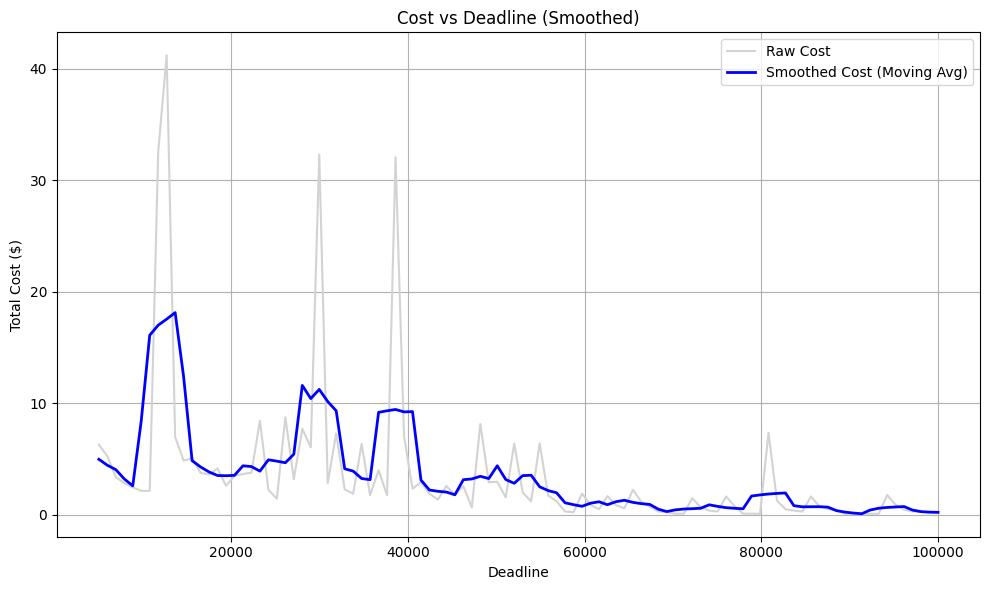

In [ ]:



# Optional: sort by Deadline if not already
costs_df = costs_df.sort_values("Deadline")

# Apply rolling mean (window size can be tuned)
costs_df["Smoothed"] = costs_df["Cost"].rolling(window=5, min_periods=1, center=True).mean()

# Plot raw and smoothed
plt.figure(figsize=(10, 6))
plt.plot(costs_df["Deadline"], costs_df["Cost"], color='lightgray', label='Raw Cost')
plt.plot(costs_df["Deadline"], costs_df["Smoothed"], color='blue', linewidth=2, label='Smoothed Cost (Moving Avg)')

plt.xlabel("Deadline")
plt.ylabel("Total Cost ($)")
plt.title("Cost vs Deadline (Smoothed)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


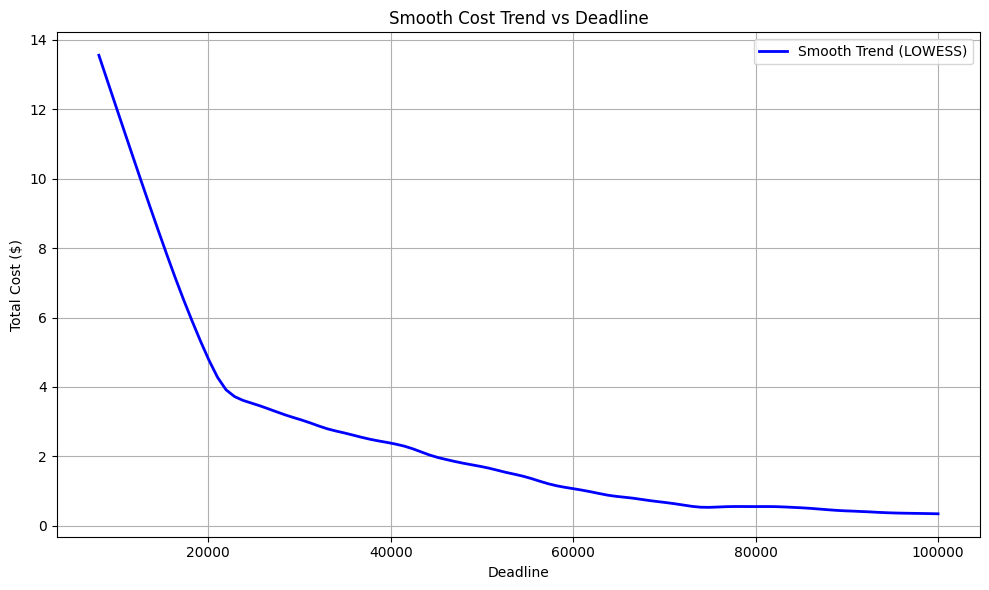

In [ ]:


# Ensure your data is sorted
costs_df = costs_df.sort_values("Deadline")

# Apply LOWESS smoothing
lowess = sm.nonparametric.lowess
smoothed = lowess(endog=costs_df["Cost"], exog=costs_df["Deadline"], frac=0.2)  # frac controls smoothness

# Plot smooth mean trend only
plt.figure(figsize=(10, 6))
plt.plot(smoothed[:, 0], smoothed[:, 1], color='blue', linewidth=2, label='Smooth Trend (LOWESS)')

plt.xlabel("Deadline")
plt.ylabel("Total Cost ($)")
plt.title("Smooth Cost Trend vs Deadline")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
df=pd.read_csv("workflow-wise-costs.csv")

Index(['Workflow', 'Deadline', 'Cost'], dtype='object')

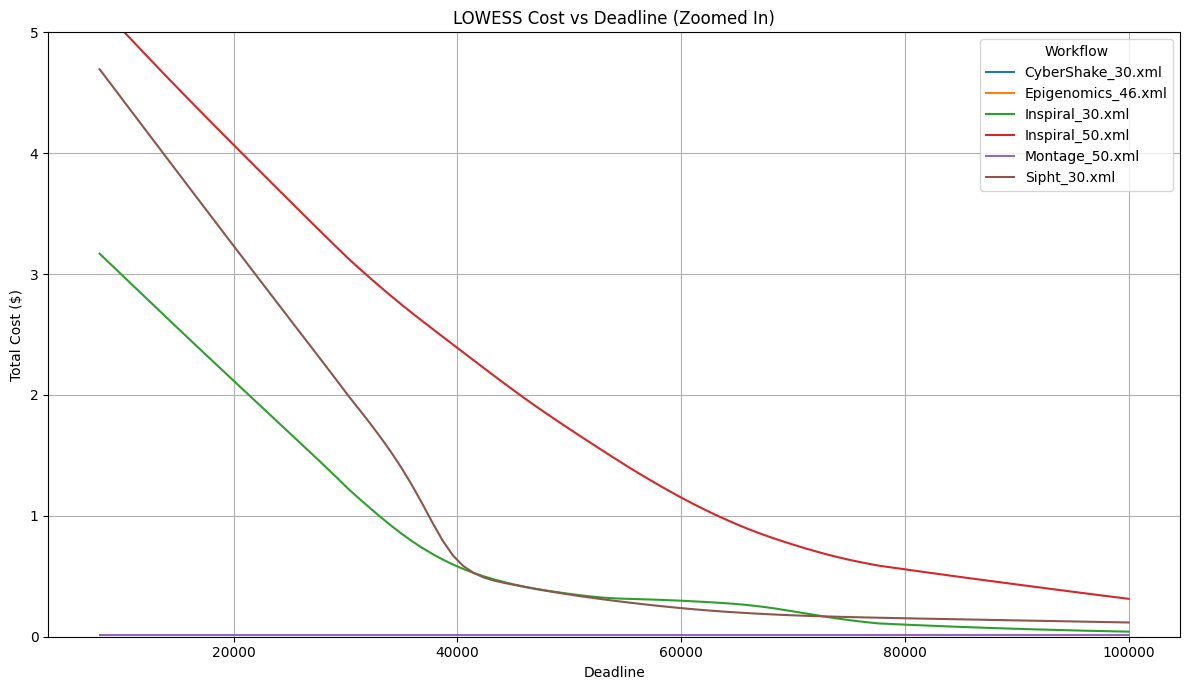

In [24]:

plt.figure(figsize=(12, 7))

for workflow in df["Workflow"].unique():
    workflow_df = df[df["Workflow"] == workflow].sort_values("Deadline")

    if len(workflow_df) < 5:
        continue

    smoothed = sm.nonparametric.lowess(
        endog=workflow_df["Cost"],
        exog=workflow_df["Deadline"],
        frac=0.5
    )

    plt.plot(smoothed[:, 0], smoothed[:, 1], label=workflow)

plt.xlabel("Deadline")
plt.ylabel("Total Cost ($)")
plt.title("LOWESS Cost vs Deadline (Zoomed In)")
plt.grid(True)
plt.legend(title="Workflow")

# 👇 Zoom in to Cost between 0 and 10
plt.ylim(0, 5)

plt.tight_layout()
plt.show()


In [25]:
df=pd.read_csv("workflow-wise-costs.csv") ##now took 1000 points for each intevral

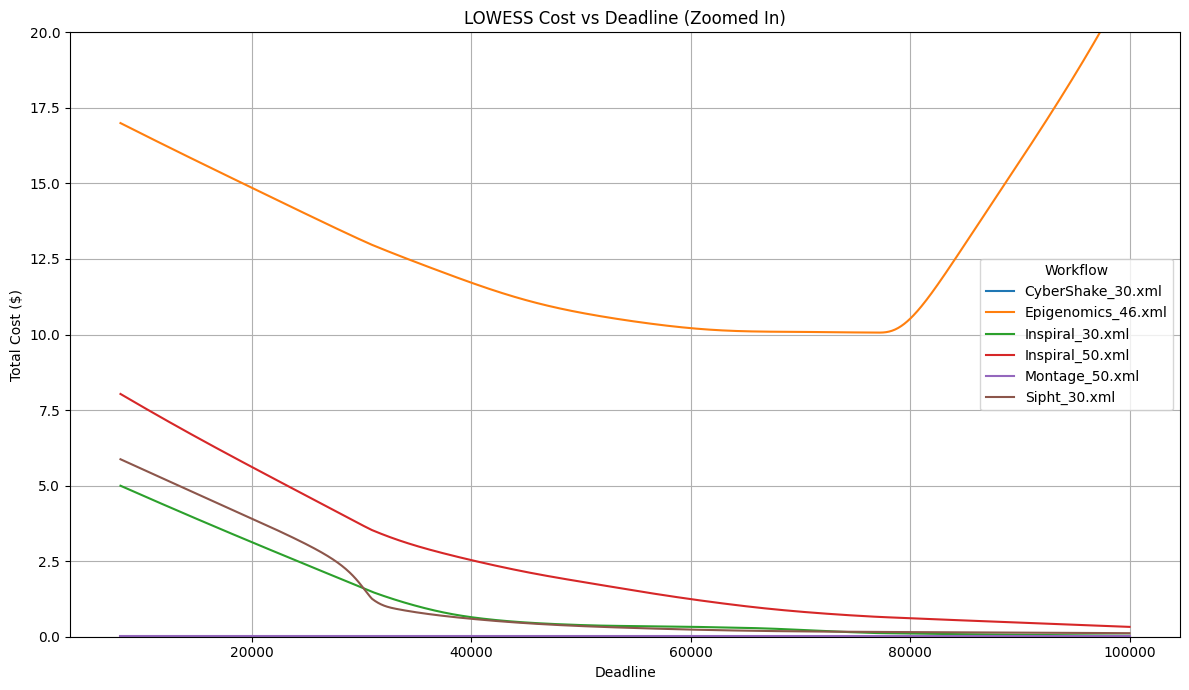

In [33]:
plt.figure(figsize=(12, 7))

for workflow in df["Workflow"].unique():
    workflow_df = df[df["Workflow"] == workflow].sort_values("Deadline")

    if len(workflow_df) < 5:
        continue

    smoothed = sm.nonparametric.lowess(
        endog=workflow_df["Cost"],
        exog=workflow_df["Deadline"],
        frac=0.5
    )

    plt.plot(smoothed[:, 0], smoothed[:, 1], label=workflow)

plt.xlabel("Deadline")
plt.ylabel("Total Cost ($)")
plt.title("LOWESS Cost vs Deadline (Zoomed In)")
plt.grid(True)
plt.legend(title="Workflow")

# 👇 Zoom in to Cost between 0 and 10
plt.ylim(0, 20)

plt.tight_layout()
plt.show()

In [34]:
df=pd.read_csv("workflow-wise-costs.csv") ##now used feadline factors


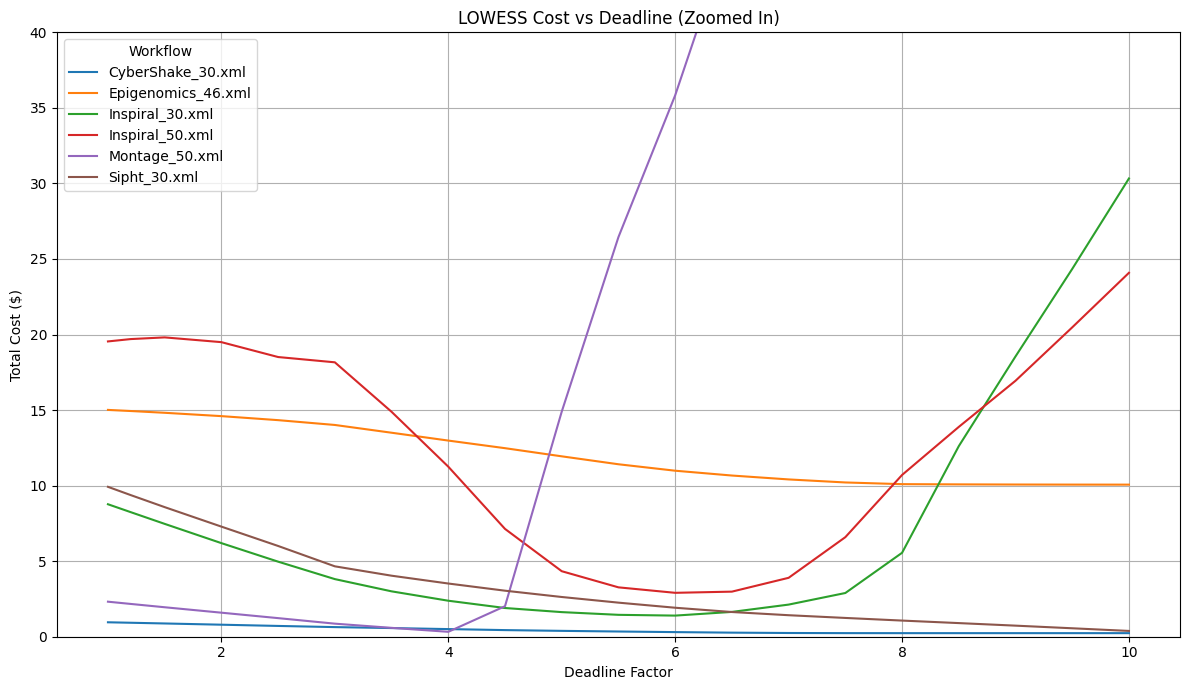

In [38]:
plt.figure(figsize=(12, 7))

for workflow in df["Workflow"].unique():
    workflow_df = df[df["Workflow"] == workflow].sort_values("Deadline")

    if len(workflow_df) < 5:
        continue

    smoothed = sm.nonparametric.lowess(
        endog=workflow_df["Cost"],
        exog=workflow_df["Deadline"],
        frac=0.5
    )

    plt.plot(smoothed[:, 0], smoothed[:, 1], label=workflow)

plt.xlabel("Deadline Factor")
plt.ylabel("Total Cost ($)")
plt.title("LOWESS Cost vs Deadline (Zoomed In)")
plt.grid(True)
plt.legend(title="Workflow")

# 👇 Zoom in to Cost between 0 and 10
plt.ylim(0, 40)

plt.tight_layout()
plt.show()

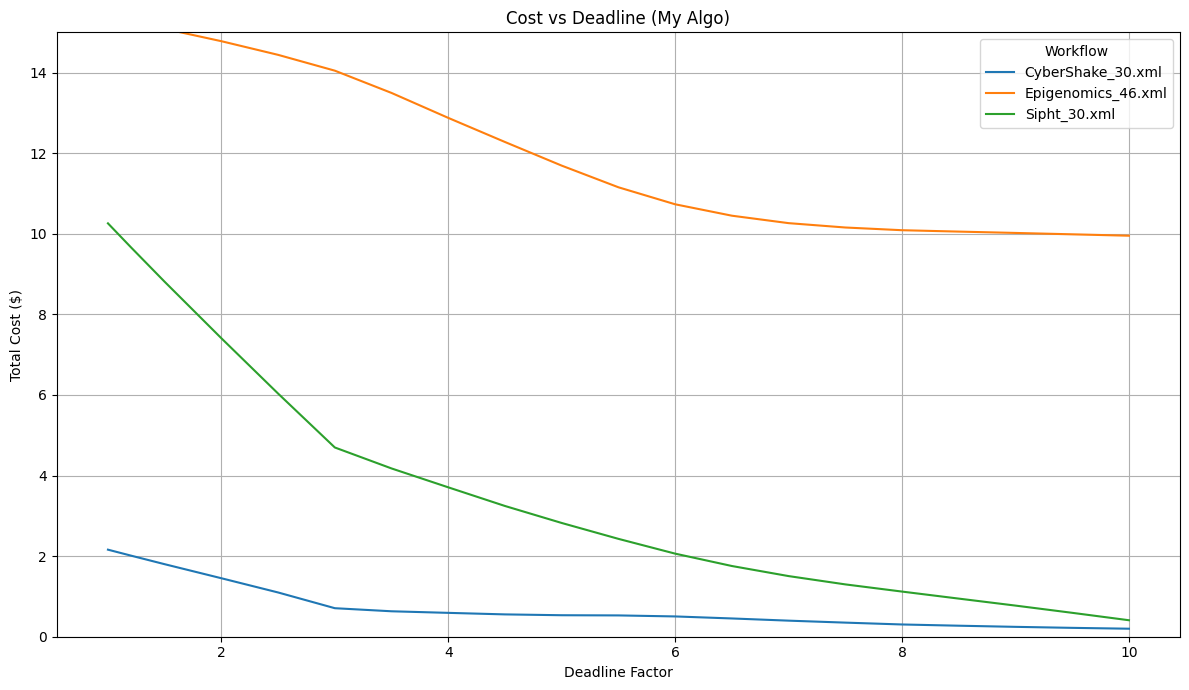

In [15]:
plt.figure(figsize=(12, 7))

# List of workflows to exclude
excluded_workflows = {"Inspiral_30.xml", "Inspiral_50.xml", "Montage_50.xml"}

for workflow in df["Workflow"].unique():
    if workflow in excluded_workflows:
        continue  # Skip Inspiral workflows

    workflow_df = df[df["Workflow"] == workflow].sort_values("Deadline")

    if len(workflow_df) < 5:
        continue

    smoothed = sm.nonparametric.lowess(
        endog=workflow_df["Cost"],
        exog=workflow_df["Deadline"],
        frac=0.5
    )

    plt.plot(smoothed[:, 0], smoothed[:, 1], label=workflow)

plt.xlabel("Deadline Factor")
plt.ylabel("Total Cost ($)")
plt.title("Cost vs Deadline (My Algo)")
plt.grid(True)
plt.legend(title="Workflow")
plt.ylim(0, 15)
plt.tight_layout()
plt.show()


In [ ]:
df=pd.read_csv("workflow-wise-costs-V2.csv") ##now used deadline factors and normlaized costs

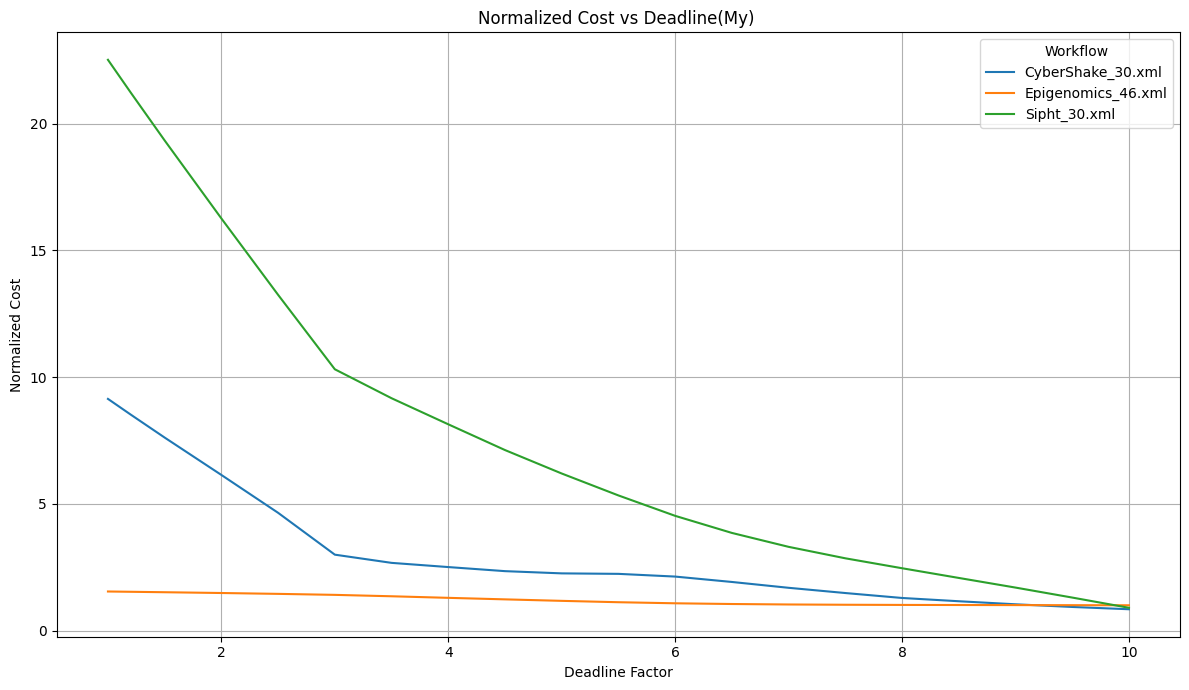

In [20]:
plt.figure(figsize=(12, 7))

excluded_workflows = {"Inspiral_30.xml", "Inspiral_50.xml", "Montage_50.xml"}

for workflow in df["Workflow"].unique():
    if workflow in excluded_workflows:
        continue

    workflow_df = df[df["Workflow"] == workflow].sort_values("Deadline")

    if len(workflow_df) < 5:
        continue

    # Normalize cost
    min_cost = workflow_df["Cost"].min()
    workflow_df["NormalizedCost"] = workflow_df["Cost"] / min_cost

    # LOWESS smoothing on normalized cost
    smoothed = sm.nonparametric.lowess(
        endog=workflow_df["NormalizedCost"],
        exog=workflow_df["Deadline"],
        frac=0.5
    )

    plt.plot(smoothed[:, 0], smoothed[:, 1], label=workflow)

plt.xlabel("Deadline Factor")
plt.ylabel("Normalized Cost")
plt.title("Normalized Cost vs Deadline(My) ")
plt.grid(True)
plt.legend(title="Workflow")
plt.tight_layout()
plt.show()


In [17]:
df_PLS=pd.read_csv("workflow-wise-costs-PLS-V1.csv") ##now used PLS model

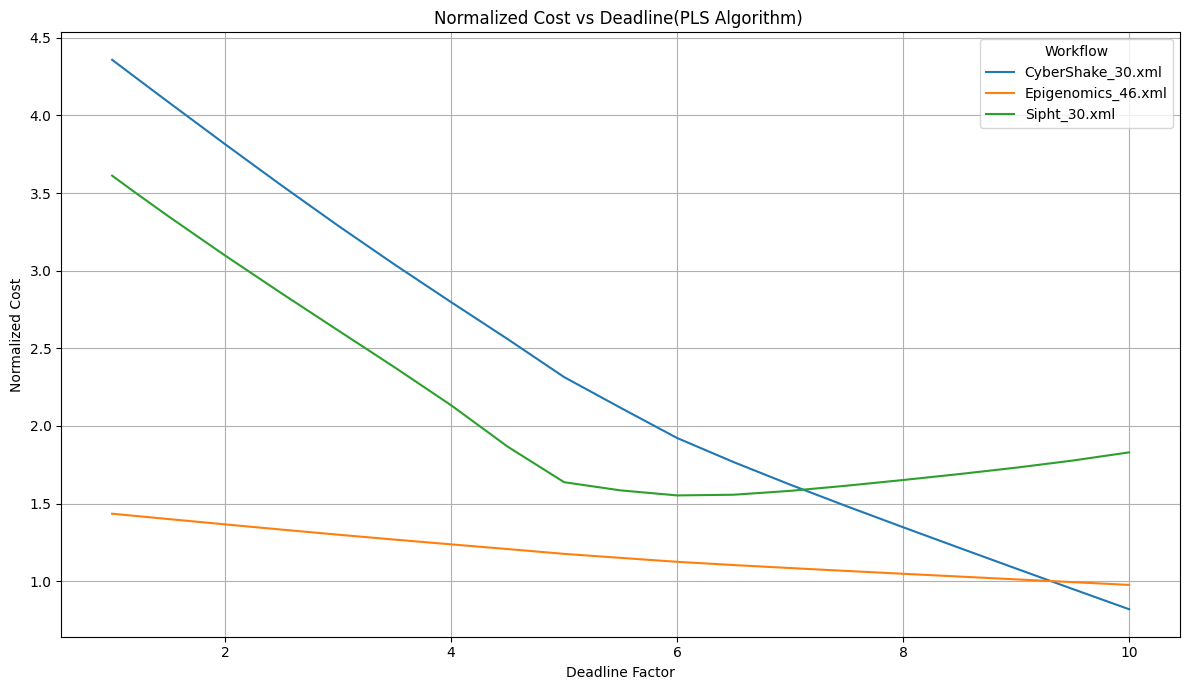

In [19]:
plt.figure(figsize=(12, 7))

excluded_workflows = {"Inspiral_30.xml", "Inspiral_50.xml", "Montage_50.xml"}

for workflow in df_PLS["Workflow"].unique():
    if workflow in excluded_workflows:
        continue

    workflow_df = df_PLS[df_PLS["Workflow"] == workflow].sort_values("Deadline")

    if len(workflow_df) < 5:
        continue

    # Normalize cost
    min_cost = workflow_df["Cost"].min()
    workflow_df["NormalizedCost"] = workflow_df["Cost"] / min_cost

    # LOWESS smoothing on normalized cost
    smoothed = sm.nonparametric.lowess(
        endog=workflow_df["NormalizedCost"],
        exog=workflow_df["Deadline"],
        frac=0.9
    )

    plt.plot(smoothed[:, 0], smoothed[:, 1], label=workflow)

plt.xlabel("Deadline Factor")
plt.ylabel("Normalized Cost")
plt.title("Normalized Cost vs Deadline(PLS Algorithm) ")
plt.grid(True)
plt.legend(title="Workflow")
plt.tight_layout()
plt.show()

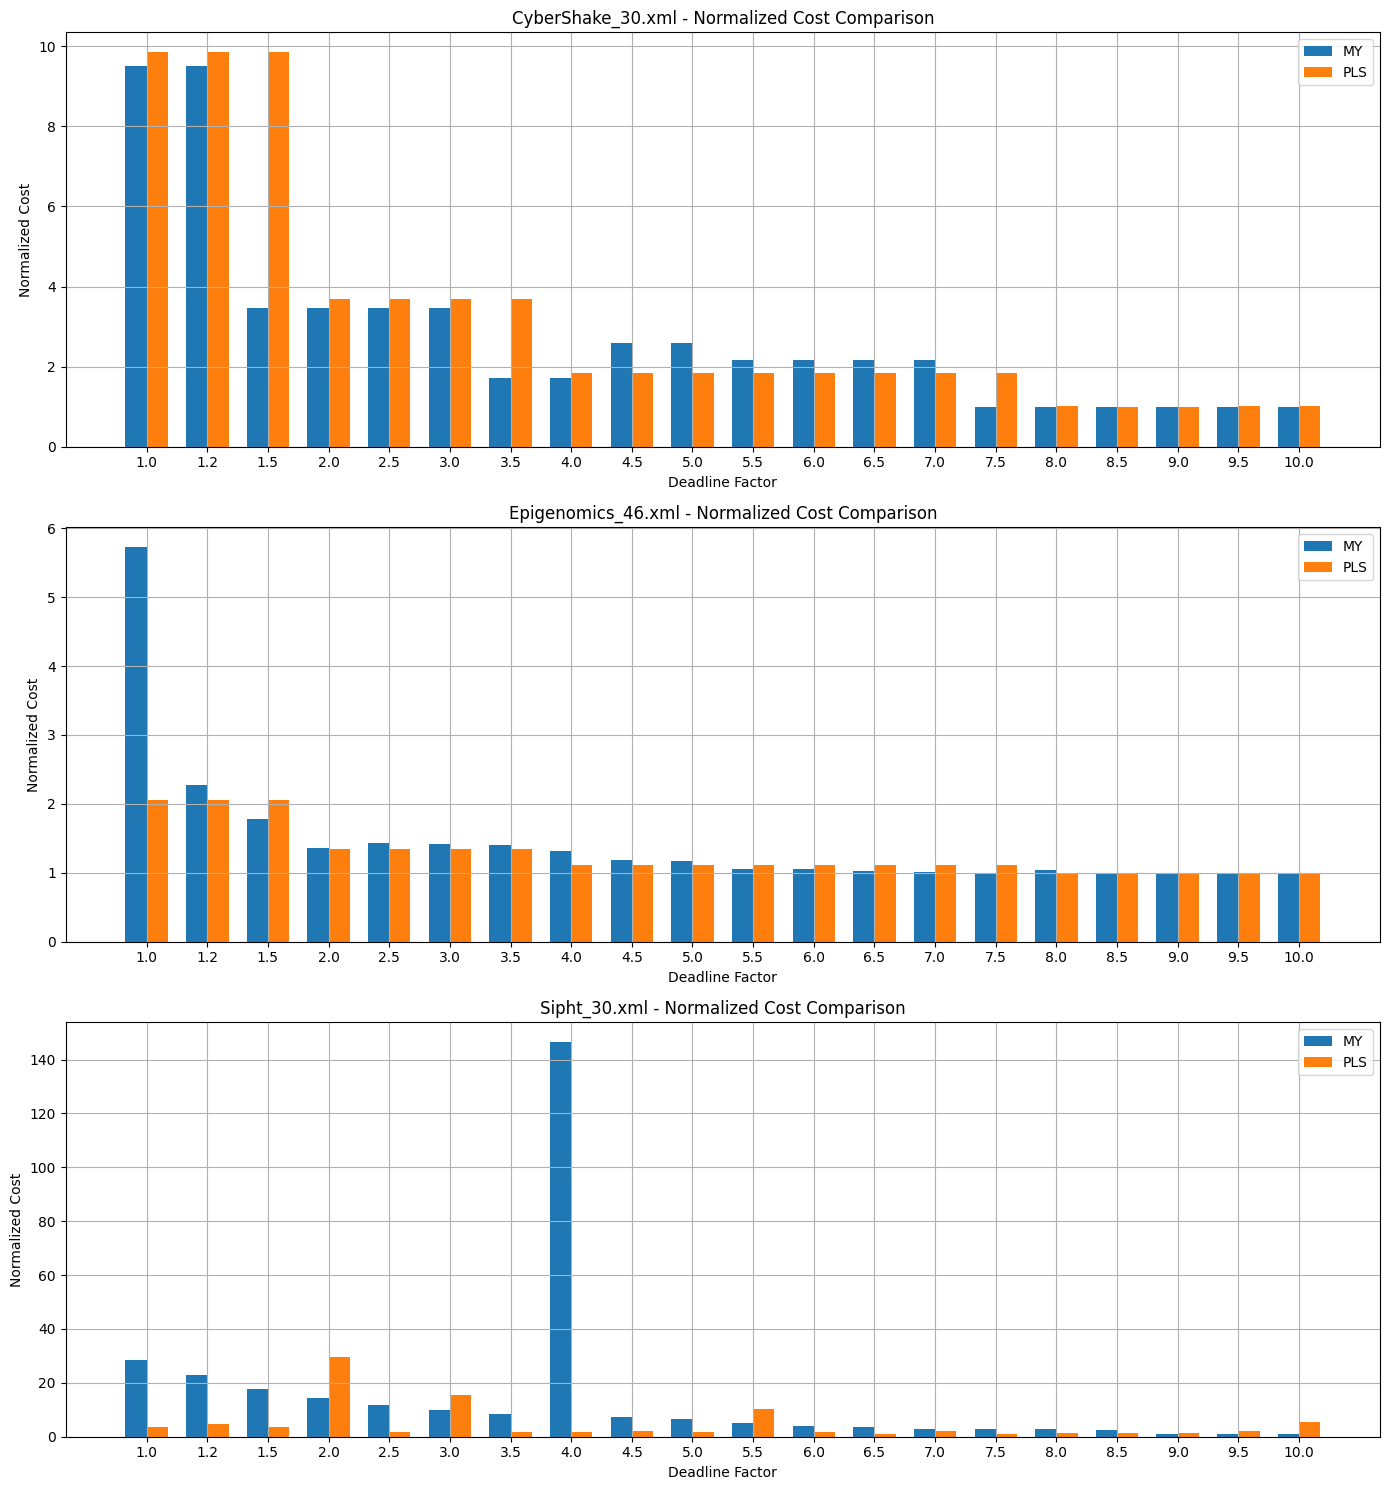

In [7]:
# Read the datasets
df_my = pd.read_csv("workflow-wise-costs-V2.csv")
df_PLS = pd.read_csv("workflow-wise-costs-PLS-V1.csv")

# Standardize columns
df_my.columns = df_my.columns.str.strip().str.capitalize()
df_PLS.columns = df_PLS.columns.str.strip().str.capitalize()

excluded_workflows = {"Inspiral_30.xml", "Inspiral_50.xml", "Montage_50.xml"}

# Merge datasets
merged_df = pd.merge(
    df_my, 
    df_PLS, 
    on=["Workflow", "Deadline"], 
    suffixes=("_My", "_PLS")
)

# Filter out excluded workflows
merged_df = merged_df[~merged_df["Workflow"].isin(excluded_workflows)]

# Plot grouped histograms per workflow
workflows = merged_df["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(14, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]  # Ensure it's iterable

for ax, workflow in zip(axs, workflows):
    wf_df = merged_df[merged_df["Workflow"] == workflow].sort_values("Deadline")

    # Normalize costs
    min_my = wf_df["Cost_My"].min()
    min_pls = wf_df["Cost_PLS"].min()

    norm_feadline = wf_df["Cost_My"] / min_my
    norm_pls = wf_df["Cost_PLS"] / min_pls

    x = np.arange(len(wf_df))
    bar_width = 0.35

    ax.bar(x - bar_width / 2, norm_feadline, width=bar_width, label='MY')
    ax.bar(x + bar_width / 2, norm_pls, width=bar_width, label='PLS')

    ax.set_xticks(x)
    ax.set_xticklabels(wf_df["Deadline"])
    ax.set_title(f"{workflow} - Normalized Cost Comparison")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

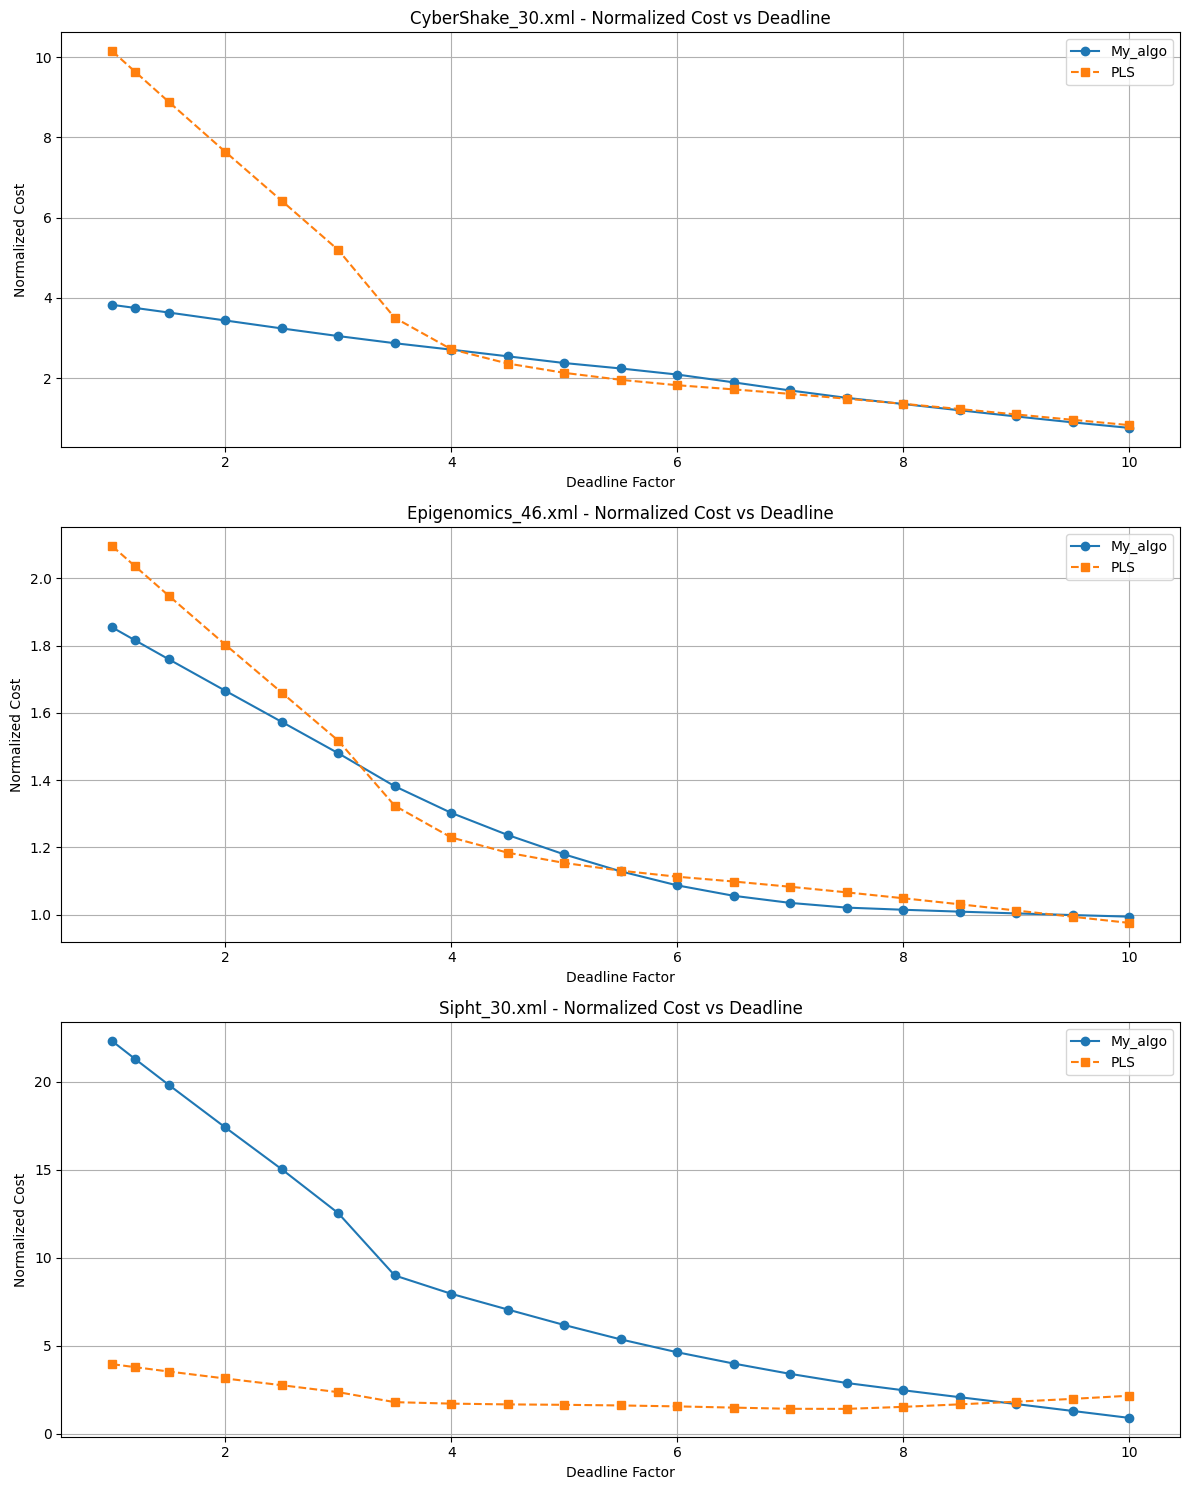

In [8]:


# Read the datasets
df_my = pd.read_csv("workflow-wise-costs-V2.csv")
df_PLS = pd.read_csv("workflow-wise-costs-PLS-V1.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()
df_PLS.columns = df_PLS.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_PLS["Deadline"] = df_PLS["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()
df_PLS["Workflow"] = df_PLS["Workflow"].str.strip()

# Merge
merged_df = pd.merge(
    df_my,
    df_PLS,
    on=["Workflow", "Deadline"],
    suffixes=("_My", "_PLS")
)

# Exclude workflows
excluded_workflows = {"Inspiral_30.xml", "Inspiral_50.xml", "Montage_50.xml"}
merged_df = merged_df[~merged_df["Workflow"].isin(excluded_workflows)]

# Plot
workflows = merged_df["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = merged_df[merged_df["Workflow"] == workflow].sort_values("Deadline")

    # Normalize costs
    min_my = wf_df["Cost_My"].min()
    min_pls = wf_df["Cost_PLS"].min()
    wf_df["Norm_Feadline"] = wf_df["Cost_My"] / min_my
    wf_df["Norm_PLS"] = wf_df["Cost_PLS"] / min_pls

    # Smooth with LOWESS
    feadline_smoothed = sm.nonparametric.lowess(wf_df["Norm_Feadline"], wf_df["Deadline"], frac=0.6)
    pls_smoothed = sm.nonparametric.lowess(wf_df["Norm_PLS"], wf_df["Deadline"], frac=0.6)

    # Plot
    ax.plot(feadline_smoothed[:, 0], feadline_smoothed[:, 1], label="My_algo", linestyle="-", marker="o")
    ax.plot(pls_smoothed[:, 0], pls_smoothed[:, 1], label="PLS", linestyle="--", marker="s")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


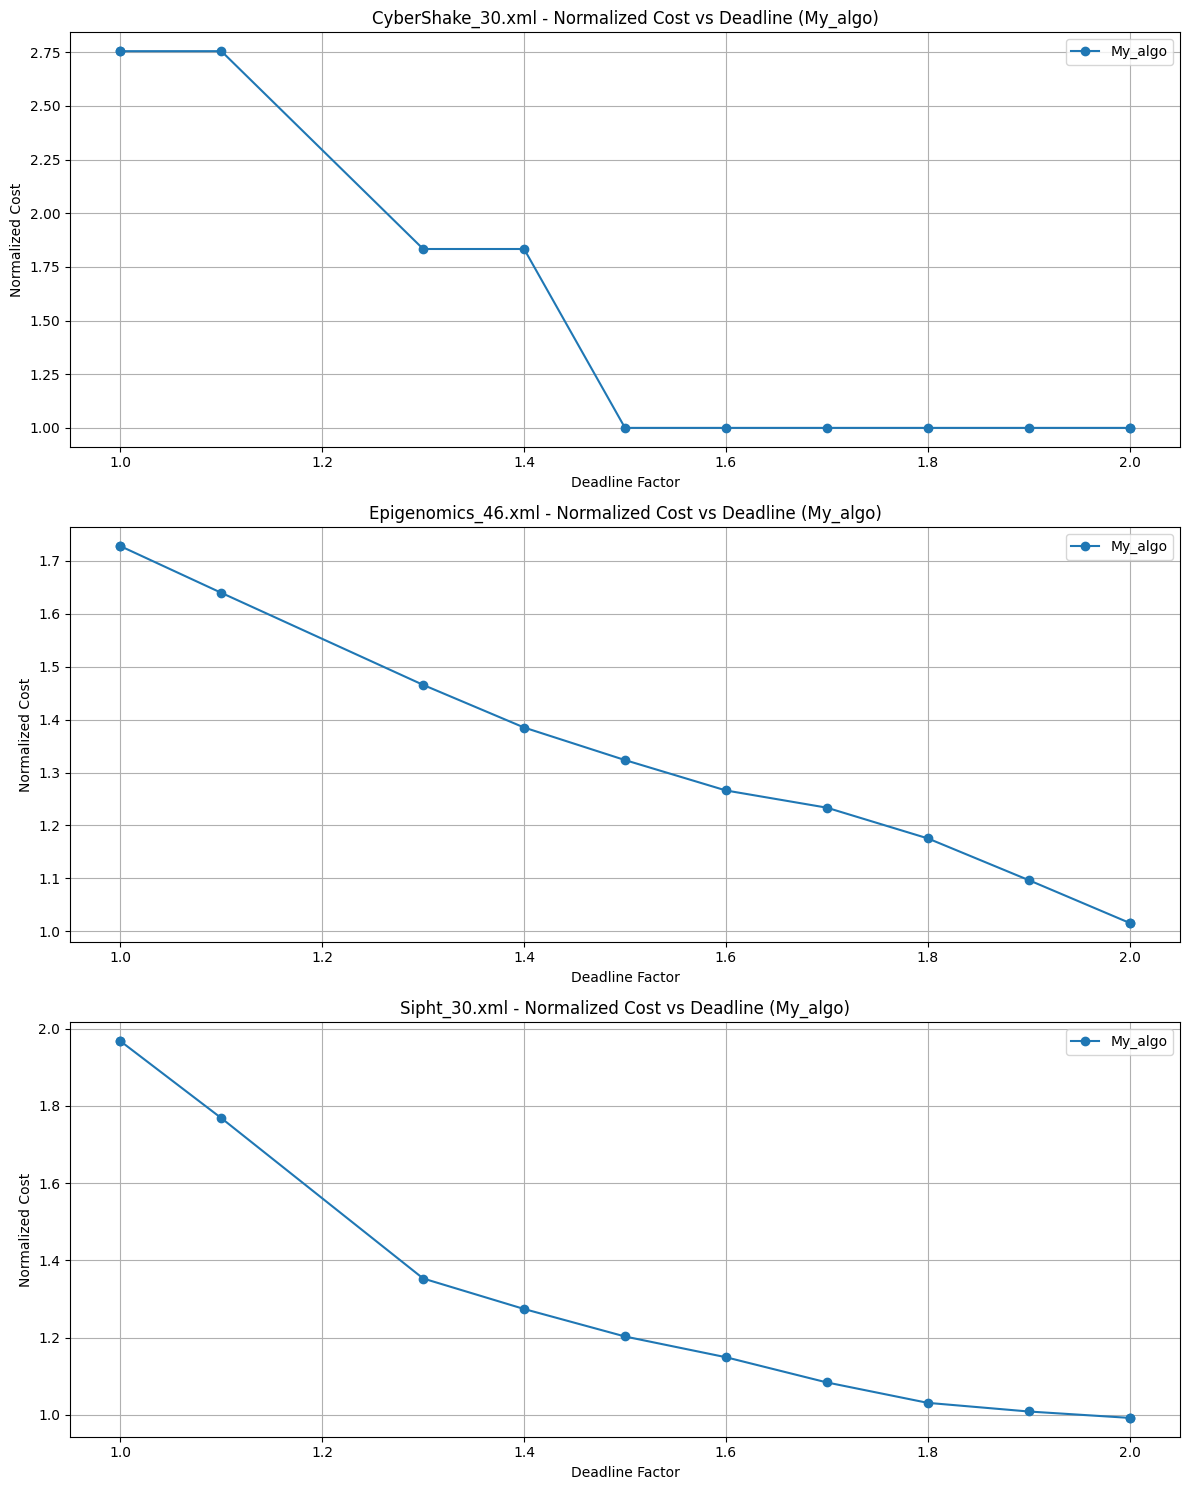

In [4]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-V4.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Inspiral_30.xml", "Inspiral_50.xml", "Montage_50.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / min_my

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.6)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Read the dataset
df_my = pd.read_csv("workflow-wise-costs-V5-billingfix.csv")

# Clean column names
df_my.columns = df_my.columns.str.strip().str.capitalize()

# Standardize types and strip workflow names
df_my["Deadline"] = df_my["Deadline"].astype(float)
df_my["Workflow"] = df_my["Workflow"].str.strip()

# Exclude specific workflows
excluded_workflows = {"Inspiral_30.xml", "Inspiral_50.xml", "Montage_50.xml"}
df_my = df_my[~df_my["Workflow"].isin(excluded_workflows)]

# Plot
workflows = df_my["Workflow"].unique()
num_workflows = len(workflows)
fig, axs = plt.subplots(nrows=num_workflows, figsize=(12, 5 * num_workflows))

if num_workflows == 1:
    axs = [axs]

for ax, workflow in zip(axs, workflows):
    wf_df = df_my[df_my["Workflow"] == workflow].sort_values("Deadline")

    # Normalize cost
    min_my = wf_df["Cost"].min()
    wf_df["Norm_Cost"] = wf_df["Cost"] / min_my

    # Smooth with LOWESS
    smoothed = sm.nonparametric.lowess(wf_df["Norm_Cost"], wf_df["Deadline"], frac=0.6)

    # Plot
    ax.plot(smoothed[:, 0], smoothed[:, 1], label="My_algo", linestyle="-", marker="o")

    ax.set_title(f"{workflow} - Normalized Cost vs Deadline (My_algo)")
    ax.set_xlabel("Deadline Factor")
    ax.set_ylabel("Normalized Cost")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()